# Multivariate Analysis
#### Definition:
        Multivariate analysis examines three or more variables simultaneously to understand complex relationships, interactions, and combined effects that cannot be detected through univariate or bivariate analysis.

#### Purpose:
        To uncover deeper patterns, multi‑variable interactions, and combined influences that shape outcomes in real‑world datasets.

#### What Multivariate Analysis Explores (Beyond Bivariate):
        Interactions among multiple variables

        Combined predictive power

        Hidden patterns that only appear when variables are analyzed together

        How variables jointly influence a target outcome

        Multicollinearity and redundancy among predictors

#### Why Multivariate Analysis Is Important
        1. Captures Real‑World Complexity: 
            Most real‑world outcomes depend on multiple factors at once, not just one or two.

            Example: Income depends on education + occupation + age + hours‑per‑week + marital status, not any single variable.
            
        2. Identifies Interaction Effects:
            Some variables only show meaningful patterns when combined.

            Example:  Education alone may not predict income strongly,  Hours‑per‑week alone may not predict income strongly, 
                     But Education × Hours‑per‑week together may show a powerful effect
                       
        3. Improves Predictive Modeling:
        
            Multivariate analysis helps identify:  Strong predictors, Weak predictors,  Redundant variables, Variables that interact or conflict, 
                 This leads to better feature engineering and more accurate models.                

        4. Detects Multicollinearity: 
            Some variables may carry the same information.

            Example: education, education_num
                     These are highly correlated and should not be used together in modeling.

        5. Supports Dimensionality Reduction
            Techniques like PCA help simplify high‑dimensional data while preserving important information.

#### Types of Multivariate Analysis
     A. Numerical + Numerical + Numerical:
         
                Used when analyzing multiple continuous variables together.

                Techniques: Multiple Linear Regression, PCA (Principal Component Analysis), Correlation Matrix, Pairplot (Seaborn)

                Visualizations: Heatmap, Pairplot, 3D Scatter Plot
                
                Examples:  
                Age + Hours‑per‑week + Capital‑gain       

       B. Categorical + Categorical + Categorical:
       
                 Used when analyzing multiple categorical variables.

                 Techniques: Multi‑way Crosstab, Chi‑Square for multiple variables, Clustered Bar Charts, Mosaic Plots

                 Examples:  
                    Workclass × Education × Income  
                        
                    
        C. Mixed Variables (Numerical + Categorical + Categorical):
        
                Most common in real datasets.

                Techniques: Logistic Regression, Decision Trees, Random Forest Feature Importance, ANOVA with multiple factors, Interaction Plots

                Visualizations: Boxplots grouped by multiple categories, Interaction plots, Partial dependence plots
                    
                 Examples:  
                        Income ~ Education + Age + Hours‑per‑week
                   
#### Limitations of Multivariate Analysis
        1. Complexity Increases Quickly
            More variables → harder interpretation.

        2. Requires Larger Sample Sizes
            More variables need more data to avoid overfitting.

        3. Sensitive to Multicollinearity
            Highly correlated predictors distort results.

        4. Harder to Visualize
            Beyond 3 variables, visualization becomes challenging.

        5. Requires Statistical Knowledge
            Understanding interactions, coefficients, and model assumptions is essential.

#### Advantages
        1. Captures Real‑World Interactions
                Shows how variables jointly influence outcomes.

        2. Improves Predictive Accuracy
                Models become more powerful and realistic.

        3. Helps Identify Key Drivers
                Reveals which variables matter most.

        4. Supports Feature Engineering
                Interaction terms, polynomial features, grouped variables.

        5. Reduces Dimensionality
                Techniques like PCA simplify complex datasets.


#### Disadvantages
        1. Harder to Interpret
                Interactions and coefficients can be complex.

        2. Requires Careful Preprocessing
                Scaling, encoding, handling missing values.

        3. Sensitive to Outliers
                Outliers can distort multivariate models.

        4. Risk of Overfitting
                Too many variables without regularization can mislead models.


### Conclusion:
Multivariate analysis examines three or more variables together to uncover complex relationships, interactions, and combined effects that univariate and bivariate analysis cannot reveal. It provides deeper insights, improves predictive modeling, and helps identify the true drivers of outcomes. However, it requires careful handling of multicollinearity, interactions, and model complexity. Multivariate analysis is the final and most powerful stage of EDA before building robust machine learning models.

##  Comparison: Univariate vs Bivariate vs Multivariate Analysis

| Aspect | Univariate | Bivariate | Multivariate |
|-------|------------|-----------|--------------|
| **Definition** | Analysis of **one** variable | Analysis of **two** variables | Analysis of **three or more** variables |
| **Goal** | Understand distribution | Understand relationships | Understand combined effects & interactions |
| **Questions Answered** | “What does this variable look like?” | “How do these two variables relate?” | “How do multiple variables jointly influence an outcome?” |
| **Techniques** | Histograms, boxplots, frequency tables | Crosstabs, correlations, ANOVA, scatter plots | Regression, PCA, clustering, interaction models |
| **Insights** | Central tendency, spread, outliers | Associations, trends, group differences | Predictive power, interactions, multicollinearity |
| **Complexity** | Low | Medium | High |
| **Limitations** | No relationships | Only two variables at a time | Harder to interpret, needs more data |
| **Use Case** | Early EDA | Relationship exploration | Modeling & deep insights |


In [2]:
import pandas as pd          # Data manipulation
import numpy as np           # Numerical operations

import matplotlib.pyplot as plt   # Basic plotting
import seaborn as sns             # Statistical visualizations

import plotly.express as px       # Interactive plots (histograms, bar charts)

sns.set(style="whitegrid")

In [3]:
import warnings
warnings.filterwarnings("ignore")


In [4]:
df_train_test = pd.read_csv("df_train_test.csv") 

df_train_test.head()


,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income,source,capital_gain_bin,capital_loss_bin,net_capital,income_binary
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K,train,1,0,2174,0
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K,train,0,0,0,0
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K,train,0,0,0,0
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K,train,0,0,0,0
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K,train,0,0,0,0


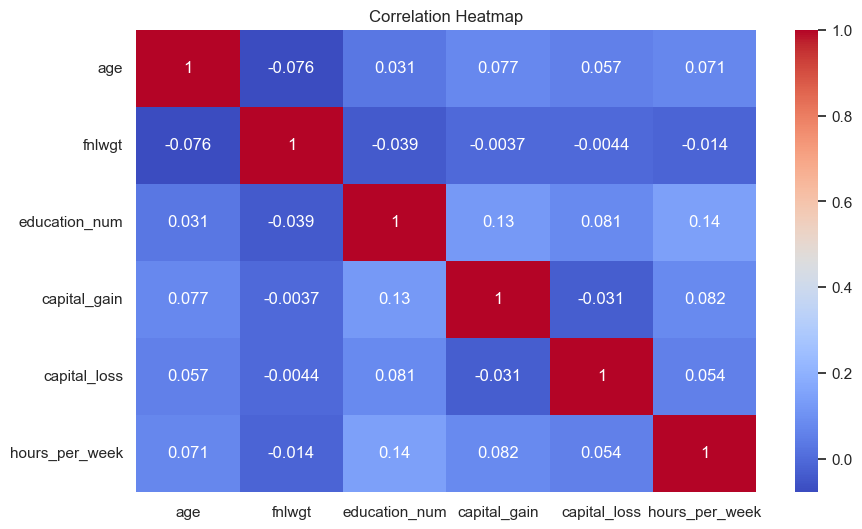

In [7]:


num_cols = ['age', 'fnlwgt', 'education_num', 'capital_gain', 'capital_loss', 'hours_per_week']

plt.figure(figsize=(10,6))
sns.heatmap(df_train_test[num_cols].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()


In [9]:
# Create age group
df_train_test['age_group'] = pd.cut(
    df_train_test['age'],
    bins=[0, 25, 35, 45, 55, 65, 100],
    labels=['<25', '25-35', '35-45', '45-55', '55-65', '65+']
)


In [13]:
df_train_test['education_grouped'] = df_train_test['education'].replace({
    'Preschool': 'Lower-Education',
    '1st-4th': 'Lower-Education',
    '5th-6th': 'Lower-Education',
    '7th-8th': 'Lower-Education',
    '9th': 'Lower-Education',
    '10th': 'Lower-Education',
    '11th': 'Lower-Education',
    '12th': 'Lower-Education',
    'HS-grad': 'High-School',
    'Some-college': 'Some-College',
    'Assoc-acdm': 'Associates',
    'Assoc-voc': 'Associates',
    'Bachelors': 'Bachelors',
    'Masters': 'Advanced-Degree',
    'Doctorate': 'Advanced-Degree',
    'Prof-school': 'Advanced-Degree'
})

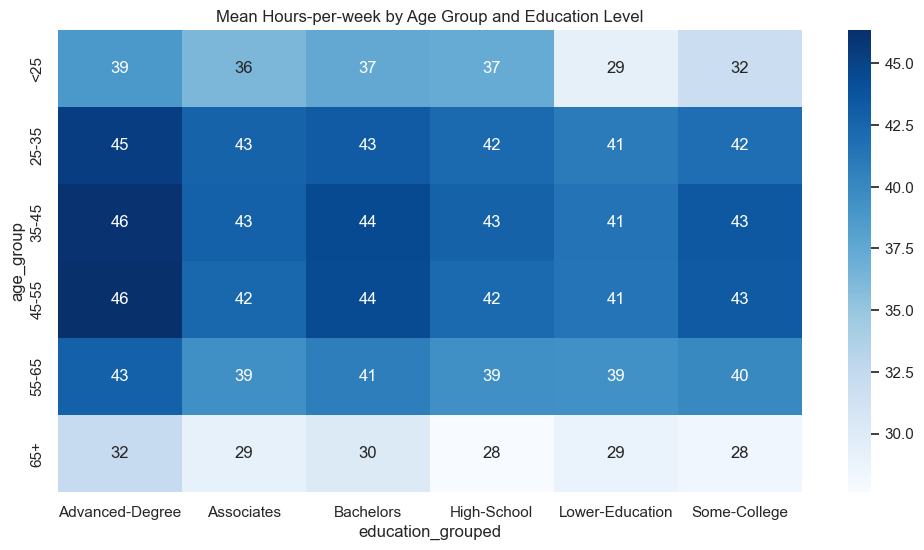

In [14]:
#Heatmap : Age groupVs EducationVs Hours

pivot_table = df_train_test.pivot_table(
    values='hours_per_week',
    index='age_group',
    columns='education_grouped',
    aggfunc='mean'
)

plt.figure(figsize=(12,6))
sns.heatmap(pivot_table, annot=True, cmap='Blues')
plt.title("Mean Hours-per-week by Age Group and Education Level")
plt.show()



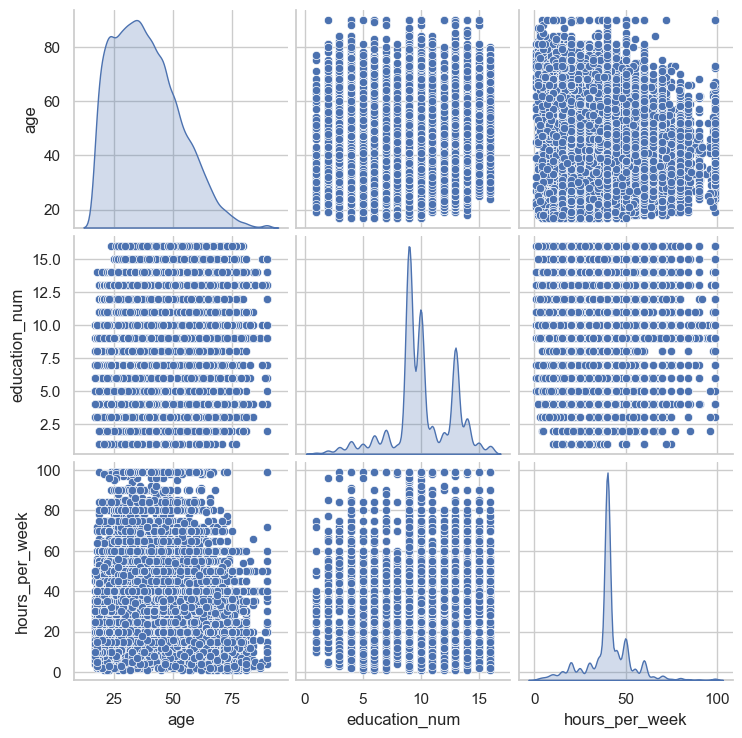

In [15]:
sns.pairplot(
    df_train_test[['age', 'education_num', 'hours_per_week']],
    kind='scatter',
    diag_kind='kde'
)
plt.show()


In [16]:
summary = df_train_test.groupby(['age_group', 'education_grouped'])['hours_per_week'].mean().round(2)
summary


age_group  education_grouped
<25        Advanced-Degree      38.79
           Associates           36.24
           Bachelors            37.43
           High-School          37.27
           Lower-Education      29.28
           Some-College         31.82
25-35      Advanced-Degree      45.27
           Associates           42.66
           Bachelors            43.22
           High-School          42.23
           Lower-Education      40.96
           Some-College         41.84
35-45      Advanced-Degree      46.07
           Associates           42.80
           Bachelors            44.46
           High-School          42.76
           Lower-Education      41.45
           Some-College         43.43
45-55      Advanced-Degree      46.34
           Associates           42.33
           Bachelors            44.39
           High-School          42.22
           Lower-Education      41.43
           Some-College         43.33
55-65      Advanced-Degree      42.83
           Associates

<Figure size 1200x600 with 0 Axes>

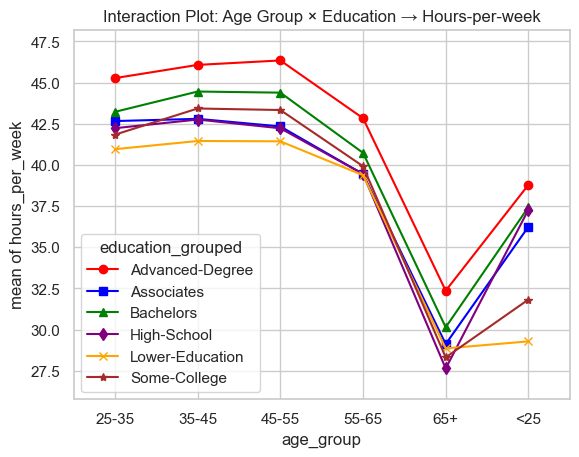

In [22]:
from statsmodels.graphics.factorplots import interaction_plot
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

interaction_plot(
    df_train_test['age_group'].astype(str),
    df_train_test['education_grouped'].astype(str),
    df_train_test['hours_per_week'],
    colors=['red','blue','green','purple','orange','brown'],
    markers=['o','s','^','d','x','*']
)

plt.title("Interaction Plot: Age Group × Education → Hours-per-week")
plt.show()


In [20]:
df_train_test['age_edu_interaction'] = df_train_test['age'] * df_train_test['education_num']

import statsmodels.formula.api as smf

model = smf.ols(
    'Q("hours_per_week") ~ age + education_num + age_edu_interaction',
    data=df_train_test
).fit()

print(model.summary())


                             OLS Regression Results                            
Dep. Variable:     Q("hours_per_week")   R-squared:                       0.026
Model:                             OLS   Adj. R-squared:                  0.026
Method:                  Least Squares   F-statistic:                     435.5
Date:                 Tue, 24 Feb 2026   Prob (F-statistic):          3.13e-279
Time:                         22:47:59   Log-Likelihood:            -1.9148e+05
No. Observations:                48813   AIC:                         3.830e+05
Df Residuals:                    48809   BIC:                         3.830e+05
Df Model:                            3                                         
Covariance Type:             nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept              2

#### workclass vs Education Vs income

#### How do different workclasses reward education levels in terms of income?
#### Why:  Education may increase income only in certain work sectors (e.g., government vs private).


In [23]:
# Crosstab and Row Percentages

ct_wc_edu = pd.crosstab(
    [df_train_test['workclass'], df_train_test['education']],
    df_train_test['income'],
    normalize='index'
).round(3)

ct_wc_edu


income                    <=50K   >50K
workclass   education                 
Federal-gov 10th          1.000  0.000
            11th          0.929  0.071
            12th          0.875  0.125
            1st-4th       1.000  0.000
            5th-6th       1.000  0.000
...                         ...    ...
Unknown     Some-college  0.940  0.060
Without-pay 7th-8th       1.000  0.000
            Assoc-acdm    1.000  0.000
            HS-grad       0.857  0.143
            Some-college  1.000  0.000

[119 rows x 2 columns]

In [26]:
df_train_test['workclass_grouped'] = df_train_test['workclass'].replace({
    'Federal-gov': 'Government',
    'State-gov': 'Government',
    'Local-gov': 'Government',
    'Self-emp-inc': 'Self-Employed',
    'Self-emp-not-inc': 'Self-Employed',
    'Without-pay': 'Not-Working',
    'Never-worked': 'Not-Working',
    'Unknown': 'Unknown',
    'Private': 'Private'
})

In [30]:
ct_counts = pd.crosstab(
    [df_train_test['workclass_grouped'], df_train_test['education_grouped']],
    df_train_test['income']
)

ct_counts


income                               <=50K  >50K
workclass_grouped education_grouped             
Government        Advanced-Degree      523   678
                  Associates           378   155
                  Bachelors            917   527
                  High-School         1255   316
                  Lower-Education      336    22
                  Some-College        1122   320
Not-Working       Associates             2     0
                  High-School           14     2
                  Lower-Education        8     0
                  Some-College           5     0
Private           Advanced-Degree      770  1229
                  Associates          1938   634
                  Bachelors           3085  2213
                  High-School         9977  1698
                  Lower-Education     4565   243
                  Some-College        6159  1368
Self-Employed     Advanced-Degree      227   548
                  Associates           275   124
                  Bachelors            512   513
                  High-School         1285   420
                  Lower-Education      510    86
                  Some-College         731   324
Unknown           Advanced-Degree       57    52
                  Associates           133    22
                  Bachelors            193    60
                  High-School          744    66
                  Lower-Education      617    15
                  Some-College         790    50

In [33]:

ct_percent = pd.crosstab(
    [df_train_test['workclass_grouped'], df_train_test['education_grouped']],
    df_train_test['income'],
    normalize='index'
).round(3)

ct_percent

ct_percent_display = (ct_percent * 100).round(1).astype(str) + '%'
ct_percent_display



income                                <=50K   >50K
workclass_grouped education_grouped               
Government        Advanced-Degree     43.5%  56.5%
                  Associates          70.9%  29.1%
                  Bachelors           63.5%  36.5%
                  High-School         79.9%  20.1%
                  Lower-Education     93.9%   6.1%
                  Some-College        77.8%  22.2%
Not-Working       Associates         100.0%   0.0%
                  High-School         87.5%  12.5%
                  Lower-Education    100.0%   0.0%
                  Some-College       100.0%   0.0%
Private           Advanced-Degree     38.5%  61.5%
                  Associates          75.3%  24.7%
                  Bachelors           58.2%  41.8%
                  High-School         85.5%  14.5%
                  Lower-Education     94.9%   5.1%
                  Some-College        81.8%  18.2%
Self-Employed     Advanced-Degree     29.3%  70.7%
                  Associates          68.9%  31.1%
                  Bachelors           50.0%  50.0%
                  High-School         75.4%  24.6%
                  Lower-Education     85.6%  14.4%
                  Some-College        69.3%  30.7%
Unknown           Advanced-Degree     52.3%  47.7%
                  Associates          85.8%  14.2%
                  Bachelors           76.3%  23.7%
                  High-School         91.9%   8.1%
                  Lower-Education     97.6%   2.4%
                  Some-College        94.0%   6.0%

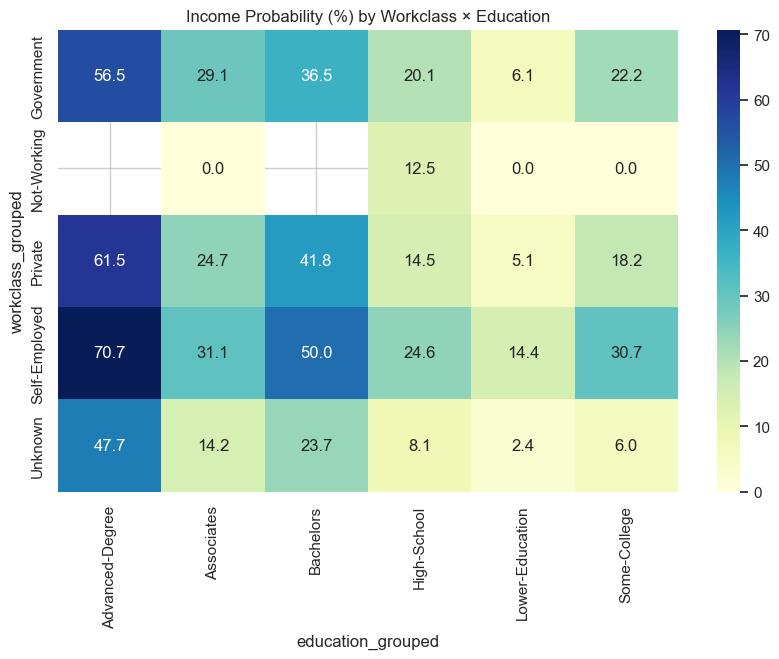

In [34]:
pivot = df_train_test.pivot_table(
    values='income_binary',
    index='workclass_grouped',
    columns='education_grouped',
    aggfunc='mean'
) * 100

plt.figure(figsize=(10,6))
sns.heatmap(pivot, annot=True, fmt='.1f', cmap='YlGnBu')
plt.title("Income Probability (%) by Workclass × Education")
plt.show()


## 1. Highest Income Groups
From the heatmap, the top‑earning combinations (highest probability of >50K) are:

Self‑Employed + Advanced Degree → ~70.7%
This is the highest income probability in the entire matrix.

 Private + Advanced Degree → ~61.5%
 
Government + Advanced Degree → ~56.5%

Insight
Across all workclasses, Advanced‑Degree holders consistently show the highest income probability, with Self‑Employed individuals benefiting the most.

## 2. Lowest Income Groups
The lowest‑earning combinations (lowest probability of >50K) are:

 Not‑Working + Lower Education → 0%
(Also 0% for Associates and Some‑College)

 Unknown + Lower Education → ~2.4%
 
 Private + Lower Education → ~5.1%
Insight
Individuals with Lower Education have extremely low income probability across all workclasses, especially in:

Not‑Working, Unknown, Private

This shows a strong disadvantage for low‑education groups.

## 3. Interaction Effect (Education × Workclass)
Here’s the key  insight:

A. Education has a strong positive effect across all workclasses
Income probability increases monotonically as education level rises.

B. The strength of this effect varies by workclass
Self‑Employed benefit the most from higher education
(Advanced Degree → 70.7%, Bachelors → 50%)

Government shows stable but moderate gains
(Advanced Degree → 56.5%, Bachelors → 36.5%)

Private shows strong gains but less than Self‑Employed
(Advanced Degree → 61.5%, Bachelors → 41.8%)

Unknown workclass shows the weakest education effect
(Advanced Degree → 47.7%, Bachelors → 23.7%)

C. Lower‑Education groups remain low regardless of workclass
Even in Self‑Employed or Government roles, Lower‑Education individuals rarely exceed 15%.

D. Not‑Working group shows almost no benefit from education
Even High‑School or Some‑College individuals have very low income probability.

## 4. Conclusion: 
    Education and workclass interact strongly to influence income.
    
    Higher education boosts income probability in every workclass, but the magnitude differs:

    Self‑Employed gain the most from higher education

    Government roles reward education consistently

    Private sector shows moderate but clear gains

    Unknown and Not‑Working groups show limited benefit

    This demonstrates a clear three‑way interaction:

    Income is highest when both education level and workclass quality are high.

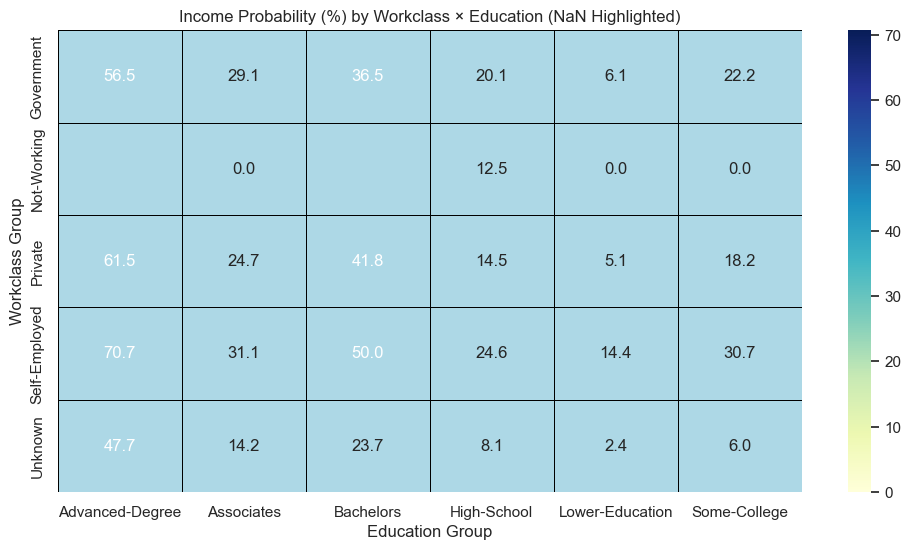

In [36]:
plt.figure(figsize=(12,6))

sns.heatmap(
    pivot,
    annot=True,
    fmt='.1f',
    cmap='YlGnBu',
    cbar=True,
    linewidths=0.5,
    linecolor='black',
    mask=pivot.isnull(),      # mask NaN cells
    square=False
)

# Overlay NaN cells in a different color
sns.heatmap(
    pivot.isnull(),
    cmap=['lightblue'],       # color for NaN
    cbar=False,
    linewidths=0.5,
    linecolor='black'
)

plt.title("Income Probability (%) by Workclass × Education (NaN Highlighted)")
plt.xlabel("Education Group")
plt.ylabel("Workclass Group")
plt.show()
